In [3]:
import csv
import math
import random

In [4]:
rows = []
with open('dataset_processed.csv', 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

feature_cols = [c for c in rows[0].keys() if c not in ('url', 'status')]
n = len(rows)
print(n, "rows,", len(feature_cols), "features")

11430 rows, 48 features


In [5]:
X = [[float(r[col]) for col in feature_cols] for r in rows]
y = [1 if r['status'] == 'phishing' else 0 for r in rows]

In [6]:
split_train = int(0.6 * n)
split_val   = int(0.8 * n)

X_train = X[:split_train]
y_train = y[:split_train]

X_val   = X[split_train:split_val]
y_val   = y[split_train:split_val]

X_test  = X[split_val:]
y_test  = y[split_val:]

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

Train: 6858
Val  : 2286
Test : 2286


In [7]:
def gini(groups, classes):
    total = sum(len(g) for g in groups)
    score = 0.0
    for group in groups:
        size = len(group)
        if size == 0:
            continue
        proportions = [group.count(c) / size for c in classes]
        score += (1 - sum(p ** 2 for p in proportions)) * (size / total)
    return score

In [12]:
def best_split(X, y, depth=1):
    best_idx, best_val, best_score, best_groups = None, None, 1, None
    classes = list(set(y))
    total_cols = len(X[0])

    for col in range(total_cols):
        print(f"  Depth {depth} — scanning feature {col+1}/{total_cols}", end='\r')

        vals = [row[col] for row in X]
        lo, hi = min(vals), max(vals)
        
        # try only 20 evenly spaced thresholds instead of every row
        thresholds = [lo + (hi - lo) * t / 20 for t in range(1, 20)]

        for val in thresholds:
            left_y  = [y[i] for i in range(len(X)) if X[i][col] < val]
            right_y = [y[i] for i in range(len(X)) if X[i][col] >= val]
            if not left_y or not right_y:
                continue
            score = gini([left_y, right_y], classes)
            if score < best_score:
                best_idx, best_val, best_score = col, val, score
                best_groups = (
                    [(X[i], y[i]) for i in range(len(X)) if X[i][col] < val],
                    [(X[i], y[i]) for i in range(len(X)) if X[i][col] >= val]
                )
    print()
    return best_idx, best_val, best_groups

In [13]:
def to_leaf(pairs):
    labels = [p[1] for p in pairs]
    return max(set(labels), key=labels.count)

def build_tree(pairs, max_depth, min_size, depth=1):
    X = [p[0] for p in pairs]
    y = [p[1] for p in pairs]
    print(f"  Building depth {depth}/{max_depth} — {len(pairs)} samples")
    idx, val, groups = best_split(X, y, depth)
    if not groups or idx is None:
        return to_leaf(pairs)
    left_pairs, right_pairs = groups
    if depth >= max_depth:
        return {'idx': idx, 'val': val,
                'left': to_leaf(left_pairs),
                'right': to_leaf(right_pairs)}
    node = {'idx': idx, 'val': val}
    node['left']  = to_leaf(left_pairs)  if len(left_pairs)  <= min_size else build_tree(left_pairs,  max_depth, min_size, depth + 1)
    node['right'] = to_leaf(right_pairs) if len(right_pairs) <= min_size else build_tree(right_pairs, max_depth, min_size, depth + 1)
    return node

def predict_one(node, row):
    if not isinstance(node, dict):
        return node
    if row[node['idx']] < node['val']:
        return predict_one(node['left'], row)
    return predict_one(node['right'], row)

In [14]:
def bootstrap_sample(X, y, seed):
    random.seed(seed)
    n = len(X)
    indices = [random.randint(0, n - 1) for _ in range(n)]
    return [X[i] for i in indices], [y[i] for i in indices]

In [15]:
NUM_TREES = 10

print(f"Building Random Forest ({NUM_TREES} trees)...")
forest = []

for i in range(NUM_TREES):
    print(f"\n===== Tree {i+1}/{NUM_TREES} =====")
    X_sample, y_sample = bootstrap_sample(X_train, y_train, seed=i)
    pairs = list(zip(X_sample, y_sample))
    tree = build_tree(pairs, max_depth=5, min_size=10)
    forest.append(tree)
    print(f"Tree {i+1} complete.")

print("\nRandom Forest built.")

Building Random Forest (10 trees)...

===== Tree 1/10 =====
  Building depth 1/5 — 6858 samples
  Depth 1 — scanning feature 48/48
  Building depth 2/5 — 3203 samples
  Depth 2 — scanning feature 48/48
  Building depth 3/5 — 194 samples
  Depth 3 — scanning feature 48/48
  Building depth 4/5 — 116 samples
  Depth 4 — scanning feature 48/48
  Building depth 5/5 — 16 samples
  Depth 5 — scanning feature 48/48
  Building depth 5/5 — 100 samples
  Depth 5 — scanning feature 48/48
  Building depth 4/5 — 78 samples
  Depth 4 — scanning feature 48/48
  Building depth 5/5 — 46 samples
  Depth 5 — scanning feature 48/48
  Building depth 5/5 — 32 samples
  Depth 5 — scanning feature 48/48
  Building depth 3/5 — 3009 samples
  Depth 3 — scanning feature 48/48
  Building depth 4/5 — 2967 samples
  Depth 4 — scanning feature 48/48
  Building depth 5/5 — 2823 samples
  Depth 5 — scanning feature 48/48
  Building depth 5/5 — 144 samples
  Depth 5 — scanning feature 48/48
  Building depth 4/5 — 42 sam

In [16]:
def predict_forest(forest, row):
    votes = [predict_one(tree, row) for tree in forest]
    return 1 if votes.count(1) >= votes.count(0) else 0

print("Predicting train set...")
train_pred = [predict_forest(forest, row) for row in X_train]

print("Predicting validation set...")
val_pred   = [predict_forest(forest, row) for row in X_val]

print("Predicting test set...")
test_pred  = [predict_forest(forest, row) for row in X_test]

print("Done.")

Predicting train set...
Predicting validation set...
Predicting test set...
Done.


In [17]:
def evaluate(y_true, y_pred, label=""):
    TP = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 1)
    TN = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 0)
    FP = sum(1 for a, p in zip(y_true, y_pred) if a == 0 and p == 1)
    FN = sum(1 for a, p in zip(y_true, y_pred) if a == 1 and p == 0)
    total = TP + TN + FP + FN

    accuracy        = (TP + TN) / total
    error_rate      = (FP + FN) / total
    precision       = TP / (TP + FP)                               if (TP + FP) > 0 else 0
    recall          = TP / (TP + FN)                               if (TP + FN) > 0 else 0
    specificity     = TN / (TN + FP)                               if (TN + FP) > 0 else 0
    npv             = TN / (TN + FN)                               if (TN + FN) > 0 else 0
    f1              = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    balanced_acc    = (recall + specificity) / 2
    gmean           = math.sqrt(recall * specificity)
    mcc_num         = (TP * TN) - (FP * FN)
    mcc_den         = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc             = mcc_num / mcc_den                            if mcc_den > 0 else 0
    kappa           = mcc
    youden_j        = recall + specificity - 1
    fpr             = FP / (FP + TN)                               if (FP + TN) > 0 else 0
    fnr             = FN / (FN + TP)                               if (FN + TP) > 0 else 0
    lr_pos          = recall / fpr                                 if fpr > 0 else 0
    lr_neg          = fnr / specificity                            if specificity > 0 else 0
    dor             = lr_pos / lr_neg                              if lr_neg > 0 else 0
    prevalence      = (TP + FN) / total
    detection_rate  = TP / total
    detection_prev  = (TP + FP) / total
    prec_legit      = TN / (TN + FN)                               if (TN + FN) > 0 else 0
    rec_legit       = TN / (TN + FP)                               if (TN + FP) > 0 else 0
    f1_legit        = 2 * prec_legit * rec_legit / (prec_legit + rec_legit) if (prec_legit + rec_legit) > 0 else 0
    macro_prec      = (precision + prec_legit) / 2
    macro_rec       = (recall + rec_legit) / 2
    macro_f1        = (f1 + f1_legit) / 2
    n_legit         = TN + FP
    n_phish         = TP + FN
    weighted_prec   = (precision * n_phish + prec_legit * n_legit) / total
    weighted_rec    = (recall    * n_phish + rec_legit  * n_legit) / total
    weighted_f1     = (f1        * n_phish + f1_legit   * n_legit) / total

    print("=" * 50)
    print(f"  {label}")
    print("=" * 50)
    print("\n  CONFUSION MATRIX")
    print(f"                   Predicted")
    print(f"               Legit    Phish")
    print(f"  Actual Legit   {TN:4d}     {FP:4d}")
    print(f"  Actual Phish   {FN:4d}     {TP:4d}")
    print("\n  PRIMARY METRICS")
    print(f"  Accuracy                   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Error Rate                 : {error_rate:.4f}  ({error_rate*100:.2f}%)")
    print(f"  Precision                  : {precision:.4f}")
    print(f"  Recall / Sensitivity       : {recall:.4f}")
    print(f"  Specificity                : {specificity:.4f}")
    print(f"  NPV                        : {npv:.4f}")
    print(f"  F1-Score                   : {f1:.4f}")
    print(f"  F-Measure                  : {f1:.4f}")
    print(f"  G-Mean                     : {gmean:.4f}")
    print(f"  Balanced Accuracy          : {balanced_acc:.4f}")
    print("\n  ADVANCED METRICS")
    print(f"  MCC                        : {mcc:.4f}")
    print(f"  Cohen's Kappa              : {kappa:.4f}")
    print(f"  Youden's J Statistic       : {youden_j:.4f}")
    print(f"  Diagnostic Odds Ratio      : {dor:.4f}")
    print(f"  Positive Likelihood Ratio  : {lr_pos:.4f}")
    print(f"  Negative Likelihood Ratio  : {lr_neg:.4f}")
    print("\n  ERROR ANALYSIS")
    print(f"  False Positive Rate (FPR)  : {fpr:.4f}  ({fpr*100:.2f}%)")
    print(f"  False Negative Rate (FNR)  : {fnr:.4f}  ({fnr*100:.2f}%)")
    print(f"  Prevalence                 : {prevalence:.4f}  ({prevalence*100:.2f}%)")
    print(f"  Detection Rate             : {detection_rate:.4f}  ({detection_rate*100:.2f}%)")
    print(f"  Detection Prevalence       : {detection_prev:.4f}  ({detection_prev*100:.2f}%)")
    print("\n  PER CLASS REPORT")
    print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'Legitimate':<12} {prec_legit:>10.4f} {rec_legit:>10.4f} {f1_legit:>10.4f} {n_legit:>10}")
    print(f"  {'Phishing':<12} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {n_phish:>10}")
    print(f"  {'Macro Avg':<12} {macro_prec:>10.4f} {macro_rec:>10.4f} {macro_f1:>10.4f} {total:>10}")
    print(f"  {'Weighted Avg':<12} {weighted_prec:>10.4f} {weighted_rec:>10.4f} {weighted_f1:>10.4f} {total:>10}")
    print("=" * 50)

In [18]:
evaluate(y_train, train_pred, "TRAINING SET")
evaluate(y_val,   val_pred,   "VALIDATION SET")
evaluate(y_test,  test_pred,  "TEST SET")

  TRAINING SET

  CONFUSION MATRIX
                   Predicted
               Legit    Phish
  Actual Legit   3258      163
  Actual Phish    242     3195

  PRIMARY METRICS
  Accuracy                   : 0.9409  (94.09%)
  Error Rate                 : 0.0591  (5.91%)
  Precision                  : 0.9515
  Recall / Sensitivity       : 0.9296
  Specificity                : 0.9524
  NPV                        : 0.9309
  F1-Score                   : 0.9404
  F-Measure                  : 0.9404
  G-Mean                     : 0.9409
  Balanced Accuracy          : 0.9410

  ADVANCED METRICS
  MCC                        : 0.8821
  Cohen's Kappa              : 0.8821
  Youden's J Statistic       : 0.8819
  Diagnostic Odds Ratio      : 263.8876
  Positive Likelihood Ratio  : 19.5100
  Negative Likelihood Ratio  : 0.0739

  ERROR ANALYSIS
  False Positive Rate (FPR)  : 0.0476  (4.76%)
  False Negative Rate (FNR)  : 0.0704  (7.04%)
  Prevalence                 : 0.5012  (50.12%)
  Detection Rat

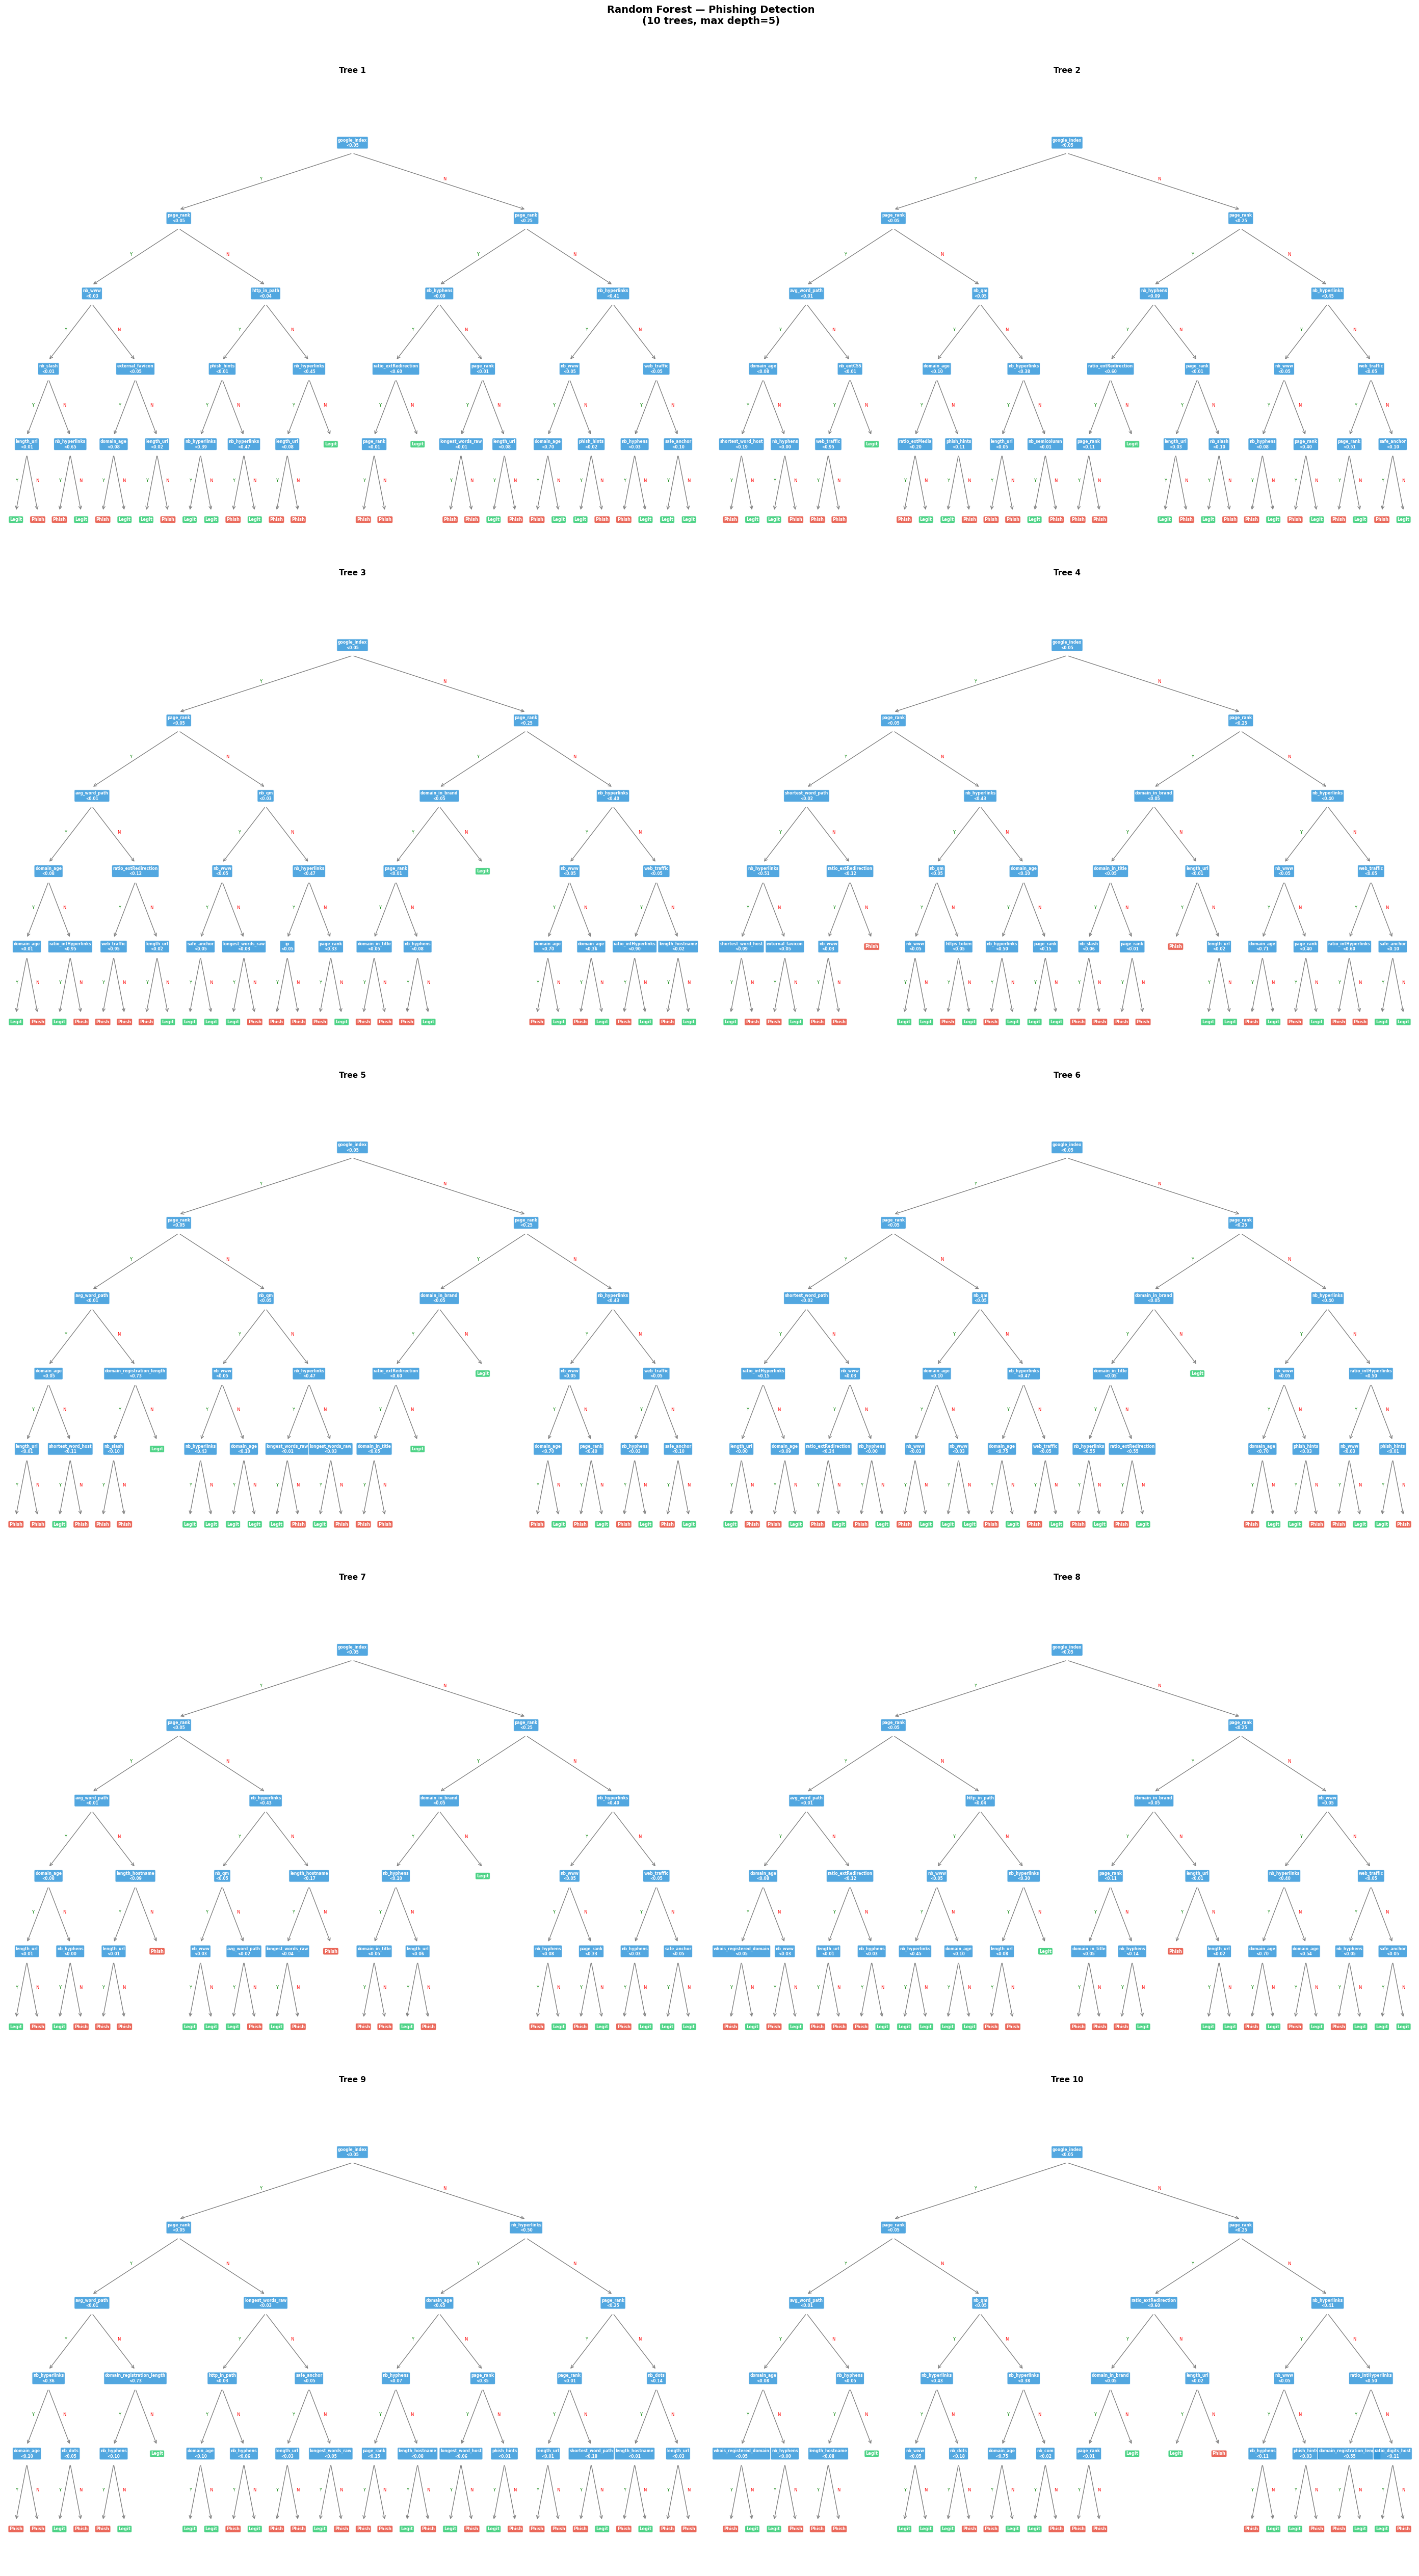

Saved: random_forest.png


In [19]:
import matplotlib.pyplot as plt

def get_tree_depth(node):
    if not isinstance(node, dict):
        return 0
    return 1 + max(get_tree_depth(node['left']), get_tree_depth(node['right']))

def count_leaves(node):
    if not isinstance(node, dict):
        return 1
    return count_leaves(node['left']) + count_leaves(node['right'])

def draw_tree(ax, node, x, y, dx, dy, depth=0):
    if not isinstance(node, dict):
        color  = '#2ecc71' if node == 0 else '#e74c3c'
        label  = 'Legit' if node == 0 else 'Phish'
        ax.text(x, y, label, ha='center', va='center', fontsize=6,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          alpha=0.85, edgecolor='white'),
                color='white', fontweight='bold')
        return

    feature_name = feature_cols[node['idx']]
    label = f"{feature_name}\n<{node['val']:.2f}"
    ax.text(x, y, label, ha='center', va='center', fontsize=5.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#3498db',
                      alpha=0.85, edgecolor='white'),
            color='white', fontweight='bold')

    # left child
    lx, ly = x - dx, y - dy
    ax.annotate('', xy=(lx, ly + 0.02), xytext=(x, y - 0.025),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.0))
    ax.text((x + lx) / 2 - 0.01, (y + ly) / 2,
            'Y', fontsize=6, color='green', ha='right')
    draw_tree(ax, node['left'],  lx, ly, dx / 2, dy, depth + 1)

    # right child
    rx, ry = x + dx, y - dy
    ax.annotate('', xy=(rx, ry + 0.02), xytext=(x, y - 0.025),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.0))
    ax.text((x + rx) / 2 + 0.01, (y + ry) / 2,
            'N', fontsize=6, color='red', ha='left')
    draw_tree(ax, node['right'], rx, ry, dx / 2, dy, depth + 1)

# --- layout ---
cols    = 2
rows_n  = math.ceil(NUM_TREES / cols)
fig, axes = plt.subplots(rows_n, cols,
                          figsize=(cols * 14, rows_n * 10))
axes = axes.flatten()

for i, tree in enumerate(forest):
    ax = axes[i]
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 0.15)
    ax.axis('off')
    ax.set_title(f'Tree {i+1}', fontsize=11,
                 fontweight='bold', pad=10)
    draw_tree(ax, tree, x=0, y=0, dx=0.5, dy=0.18)

# hide empty subplots if NUM_TREES is odd
for j in range(NUM_TREES, len(axes)):
    axes[j].axis('off')

fig.suptitle('Random Forest — Phishing Detection\n'
             f'({NUM_TREES} trees, max depth=5)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('random_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: random_forest.png")